### Data Analysis and Plotting of Hotel Ratings and Trip Type
Hey, did you know hotel ratings can really make or break a business? High ratings attract more guests and boost revenue, while low ratings can scare people away

That's where data analysts come in. They analyze customer feedback and find ways to extract insights that can improve those ratings, which can make a huge difference.

It's not just about finding these insights but also sharing them in a way that business executives can easily understand. That’s why making good visualizations is key.

In this project, we study past data to find valuable insights. We will delve into the details of creating captivating visuals that reveal the patterns and trends.

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
url = 'https://raw.githubusercontent.com/vysotskylev/tenscomp21/main/data/Data_TripAdvisor_v1.csv'

In [3]:
df = pd.read_csv(url)

In [8]:
df.shape

(4669, 9)

In [9]:
df.head()

,ID_USER,USER_STATE,USER_TIMEZONE,ID_HOTEL,HOTEL_CITY,HOTEL_STATE,HOTEL_TIMEZONE,Trip Type,Rating
0,45,GA,Eastern,105170,Memphis,TN,Central,3,5
1,45,GA,Eastern,223229,SanAntonio,TX,Central,3,5
2,45,GA,Eastern,258688,Albuquerque,NM,Mountain,3,5
3,45,GA,Eastern,98827,ELPaso,TX,Central,3,5
4,45,GA,Eastern,99518,SanAntonio,TX,Central,3,3


##### 1) Analyze Trip Type Distribution

In [37]:
trip_type_counts = df['Trip Type'].value_counts()
trip_type_counts

Trip Type
3    2062
2    1005
1     771
4     635
5     196
Name: count, dtype: int64

##### 2) Create a pie chart to identify the most popular Trip Type

<Axes: title={'center': 'Most Popular Trip Type'}, ylabel='count'>

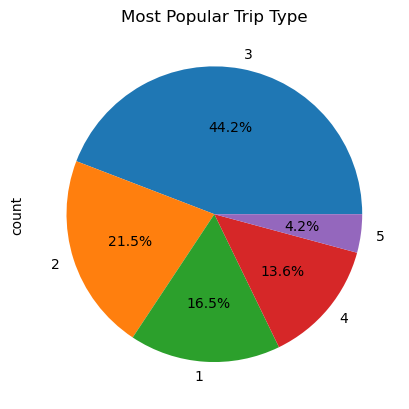

In [13]:
# Create a figure and axis
fig, ax = plt.subplots()

trip_type_counts.plot(kind="pie",
                      labels=trip_type_counts.index,
                      autopct='%1.1f%%',
                      title="Most Popular Trip Type",
                      ax=ax)

##### 3) Analyzing Hotel City Distribution

In [38]:
city_counts = df['HOTEL_CITY'].value_counts()
city_counts

HOTEL_CITY
Houston          306
SanAntonio       246
Austin           237
Albuquerque      211
Columbus         210
Indianapolis     187
Phoenix          178
OklahomaCity     174
Charlotte        167
Atlanta          164
Tucson           154
Jacksonville     137
Dallas           135
Sacramento       133
Nashville        127
Louisville       123
Wichita          122
Tulsa            117
ELPaso           114
Denver           103
Memphis          102
SanDiego          92
LasVegas          89
Portland          87
Omaha             85
FortWorth         78
LosAngeles        76
Fresno            73
Milwaukee         69
Raleigh           68
Seattle           60
SanJose           56
Arlington         55
Miami             44
Minneapolis       42
Mesa              37
Oakland           36
LongBeach         28
SanFrancisco      28
VirginiaBeach     27
Baltimore         22
Chicago           14
NewYork           12
Philadelphia      11
Cleveland         10
Boston             9
Detroit            7
Ka

##### 4) Create a bar chart to determine the most popular city where the highest number of hotels are present

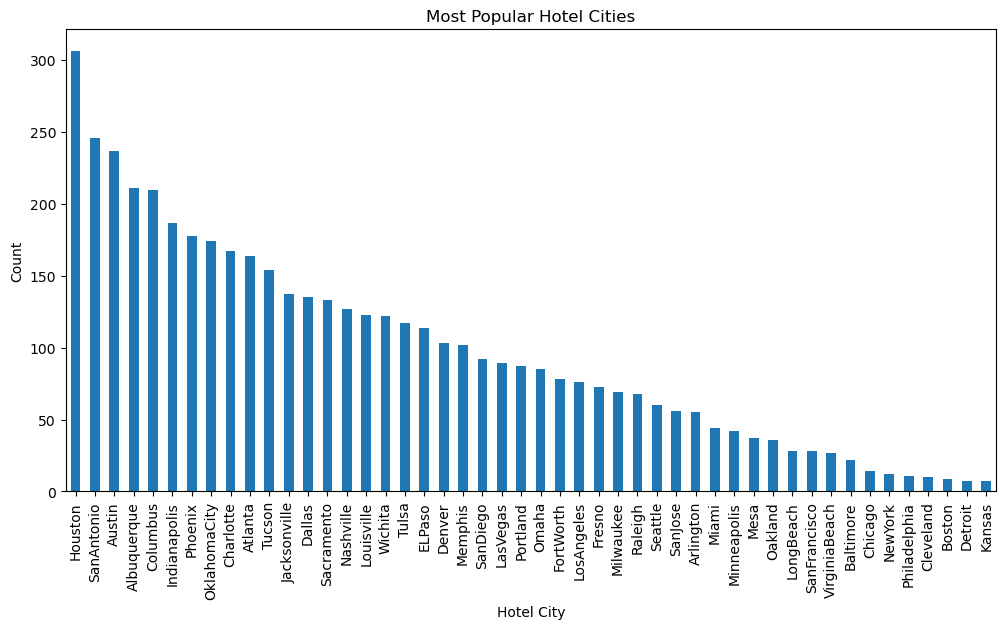

In [15]:
# Create a figure and axis
fig, ax = plt.subplots(figsize=(12, 6))

city_counts.plot(kind='bar',
                 xlabel='Hotel City',
                 ylabel='Count',
                 title='Most Popular Hotel Cities',
                 ax=ax);

##### 5) Analyzing Rating Distribution

In [39]:
rating_counts = df['Rating'].value_counts()
rating_counts

Rating
4    1771
3    1163
5    1046
2     470
1     219
Name: count, dtype: int64

##### 6) Create a bar plot to visualize the distribution of customer ratings

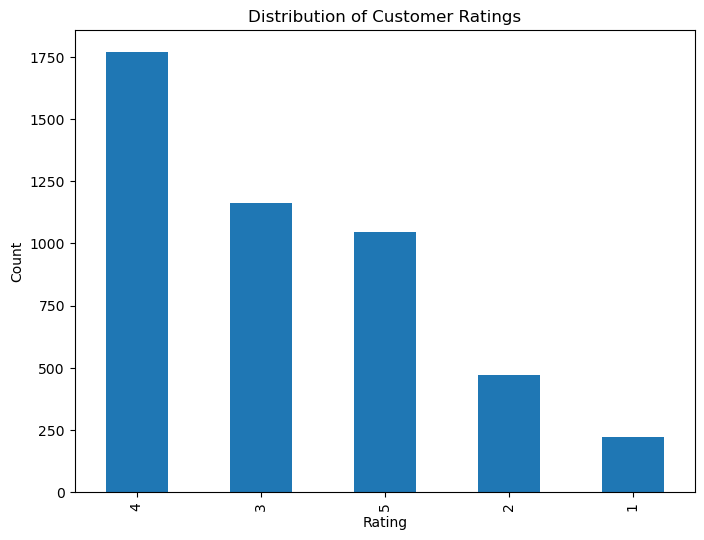

In [17]:
# Create a figure and axis
fig, ax = plt.subplots(figsize=(8, 6))

rating_counts.plot(kind='bar', 
                    xlabel='Rating', 
                    ylabel='Count', 
                    title='Distribution of Customer Ratings', 
                    ax=ax);

##### 7) Which rating was given by the most people?

In [18]:
#Rating 4 was given by the most people.

##### 8) Count Hotel Timezones

In [40]:
hotel_timezone_counts = df['HOTEL_TIMEZONE'].value_counts()
hotel_timezone_counts

HOTEL_TIMEZONE
Central     2030
Eastern     1198
Pacific      758
Mountain     683
Name: count, dtype: int64

##### 9) Calculate the percentage of each hotel timezone

In [41]:
hotel_timezone_percents = (hotel_timezone_counts / len(df)) * 100
hotel_timezone_percents

HOTEL_TIMEZONE
Central     43.478261
Eastern     25.658599
Pacific     16.234740
Mountain    14.628400
Name: count, dtype: float64

##### 10) Create a pie chart to visualize the percentage distribution of hotel timezones

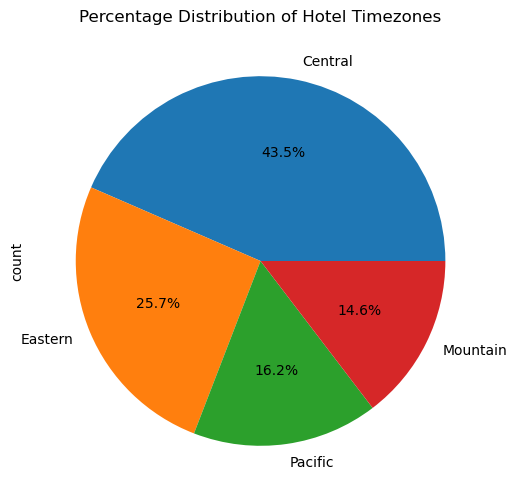

In [21]:
# Create a figure and axis
fig, ax = plt.subplots(figsize=(8, 6))

hotel_timezone_percents.plot(kind='pie',
                             labels=hotel_timezone_percents.index,
                             autopct='%1.1f%%',
                             title='Percentage Distribution of Hotel Timezones',
                             ax=ax);

##### 11) Which timezone most of the hotels are in?

In [22]:
#Most hotels are in the Central timezone.

##### 12) Create a bar chart to visualize average ratings by Hotel Timezone using subplots

In [43]:
timezone_ratings = df.pivot_table(index='HOTEL_TIMEZONE', values='Rating', aggfunc='mean').reset_index()
timezone_ratings

,HOTEL_TIMEZONE,Rating
0,Central,3.670936
1,Eastern,3.667780
2,Mountain,3.560761
3,Pacific,3.540897


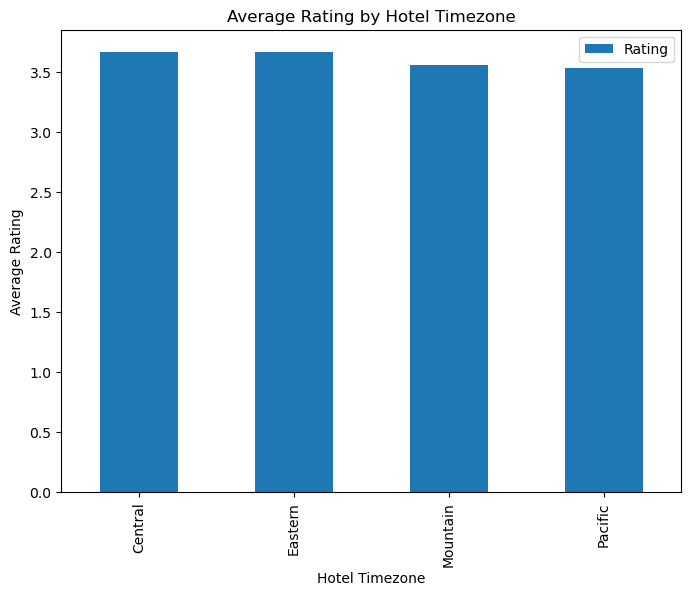

In [23]:
fig, ax = plt.subplots(figsize=(8, 6))

timezone_ratings.plot(kind='bar',
                      x='HOTEL_TIMEZONE',
                      y='Rating',
                      ax=ax,
                      xlabel='Hotel Timezone',
                      ylabel='Average Rating',
                      title='Average Rating by Hotel Timezone');

##### 13) What are the two time zones with the highest average ratings?

In [24]:
#Central and Eastern are the two timezones with the highest average ratings.

##### 14) Create a bar chart to visualize average ratings by User State using subplots

In [42]:
user_state_ratings = df.pivot_table(index='USER_STATE', values='Rating', aggfunc='mean').reset_index()
user_state_ratings = user_state_ratings.sort_values(by='Rating', ascending=False)
user_state_ratings

,USER_STATE,Rating
28,ND,4.333333
47,WV,4.333333
48,WY,4.090909
21,ME,4.000000
25,MS,4.000000
17,KY,3.967742
1,AL,3.945946
43,UT,3.933333
32,NV,3.860465
19,MA,3.857143


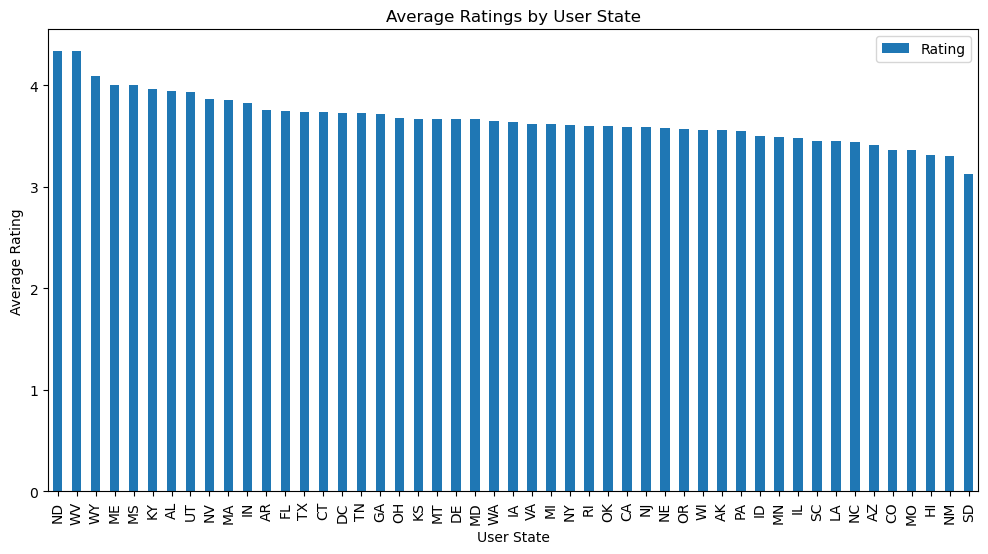

In [26]:
# Create a figure and axis
fig, ax = plt.subplots(figsize=(12, 6))

user_state_ratings.plot(kind='bar',
                        x='USER_STATE',
                        y='Rating',
                        ax=ax,
                        xlabel='User State',
                        ylabel='Average Rating',
                        title='Average Ratings by User State',
                       rot=90); # This sets the rotation directly

##### 15) Which two user states have given the highest rating?

In [27]:
#ND and WV states have given the highest rating.

##### 16) Filter top-rated hotels

In [44]:
top_rated_hotels = df[df['Rating'] >= 4]
top_rated_hotels

,ID_USER,USER_STATE,USER_TIMEZONE,ID_HOTEL,HOTEL_CITY,HOTEL_STATE,HOTEL_TIMEZONE,Trip Type,Rating
0,45,GA,Eastern,105170,Memphis,TN,Central,3,5
1,45,GA,Eastern,223229,SanAntonio,TX,Central,3,5
2,45,GA,Eastern,258688,Albuquerque,NM,Mountain,3,5
3,45,GA,Eastern,98827,ELPaso,TX,Central,3,5
5,64,TX,Central,224427,Cleveland,OH,Eastern,1,4
...,...,...,...,...,...,...,...,...,...
4658,65423,KY,Central,82636,LosAngeles,CA,Pacific,1,4
4660,65423,KY,Central,89380,Atlanta,GA,Eastern,4,5
4662,65440,MI,Eastern,92729,Albuquerque,NM,Mountain,3,5
4663,65440,MI,Eastern,95715,Minneapolis,MN,Central,3,5


##### 17) Select data for a specific hotel timezone

In [45]:
timezone = 'Eastern'
timezone_data = top_rated_hotels[top_rated_hotels['HOTEL_TIMEZONE'] == timezone]
timezone_data

,ID_USER,USER_STATE,USER_TIMEZONE,ID_HOTEL,HOTEL_CITY,HOTEL_STATE,HOTEL_TIMEZONE,Trip Type,Rating
5,64,TX,Central,224427,Cleveland,OH,Eastern,1,4
8,100,NY,Eastern,120111,Jacksonville,FL,Eastern,2,5
9,100,NY,Eastern,91428,Indianapolis,IN,Eastern,2,4
17,159,TX,Central,92773,Louisville,KY,Eastern,3,4
27,221,CT,Eastern,222955,Boston,MA,Eastern,1,5
...,...,...,...,...,...,...,...,...,...
4645,65342,CA,Pacific,224590,Jacksonville,FL,Eastern,3,5
4648,65342,CA,Pacific,88398,Jacksonville,FL,Eastern,3,5
4649,65342,CA,Pacific,91607,Indianapolis,IN,Eastern,3,4
4654,65406,FL,Eastern,91458,Indianapolis,IN,Eastern,3,5


##### 18) Get unique trip types and their counts

In [46]:
trip_types = timezone_data['Trip Type'].value_counts()
trip_types

Trip Type
3    305
2    177
1    118
4     94
5     36
Name: count, dtype: int64

##### 19) Calculate the percentage of each trip type

In [47]:
total_trips = sum(trip_types.values)
trip_type_percents = pd.Series([(count / total_trips) * 100 for count in trip_types.values], index=trip_types.index)
trip_type_percents

Trip Type
3    41.780822
2    24.246575
1    16.164384
4    12.876712
5     4.931507
dtype: float64

##### 20) Visualizing Trip Type Distribution with a Pie Chart

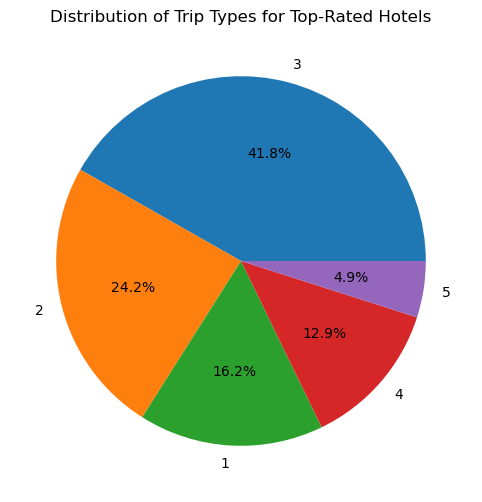

In [32]:
# Create a figure and axis
fig, ax = plt.subplots(figsize=(8, 6))

# Create a pie chart using pandas
trip_type_percents.plot(kind='pie',
                        labels=trip_types.index,
                        autopct='%1.1f%%',
                        ax=ax,
                        title='Distribution of Trip Types for Top-Rated Hotels');

##### 21) Create a bar chart to visualize regional rating trends for the top user states across hotel locations using pivoted data.

In [48]:
top_user_states = df['USER_STATE'].value_counts().nlargest(5).index
top_user_state_data = df[df['USER_STATE'].isin(top_user_states)]
top_user_state_data

,ID_USER,USER_STATE,USER_TIMEZONE,ID_HOTEL,HOTEL_CITY,HOTEL_STATE,HOTEL_TIMEZONE,Trip Type,Rating
5,64,TX,Central,224427,Cleveland,OH,Eastern,1,4
6,64,TX,Central,1751886,Austin,TX,Central,3,4
7,64,TX,Central,99120,Houston,TX,Central,3,4
15,159,TX,Central,98815,ELPaso,TX,Central,1,3
16,159,TX,Central,99055,Houston,TX,Central,2,4
...,...,...,...,...,...,...,...,...,...
4656,65406,FL,Eastern,543350,FortWorth,TX,Central,4,5
4665,65457,AZ,Mountain,1027019,FortWorth,TX,Central,3,3
4666,65457,AZ,Mountain,224458,Milwaukee,WI,Central,3,3
4667,65457,AZ,Mountain,223749,Columbus,OH,Eastern,3,2


In [33]:
user_state_timezone_ratings = top_user_state_data.pivot_table(
    index=['USER_STATE', 'HOTEL_TIMEZONE'],
    values='Rating',
    aggfunc='mean'
).reset_index()

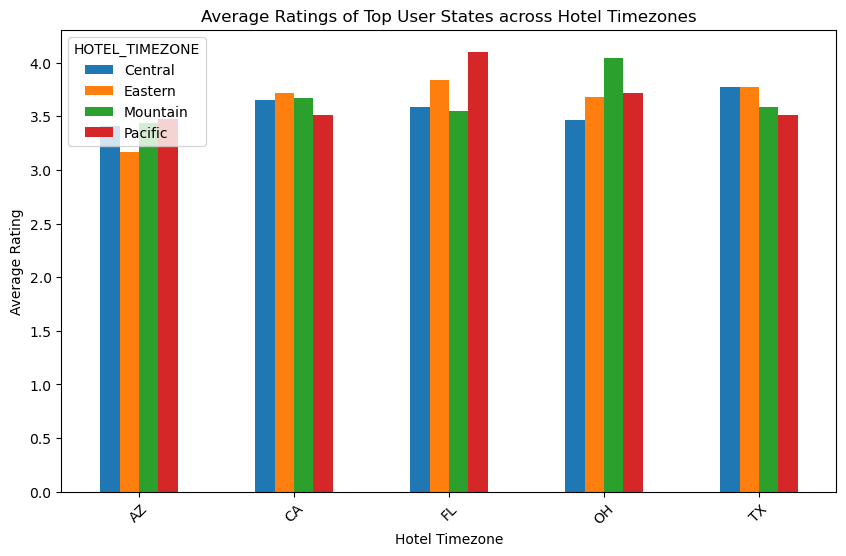

In [34]:
# Pivot the data
pivoted_timezone = user_state_timezone_ratings.pivot(index='USER_STATE', columns='HOTEL_TIMEZONE', values='Rating')

fig, ax = plt.subplots(figsize=(10, 6))

pivoted_timezone.plot(kind='bar',
                      legend=True,
                      ax=ax,
                      xlabel='Hotel Timezone',
                      ylabel='Average Rating',
                      title='Average Ratings of Top User States across Hotel Timezones',
                      rot=45);  # This sets the rotation directly


##### 22) Visualizing Average Ratings with a Bar Chart

In [35]:
top_states = df['USER_STATE'].value_counts().nlargest(5).index
top_data = df[df['USER_STATE'].isin(top_states)]
ratings = top_data.pivot_table(index=['USER_STATE', 'HOTEL_STATE'], values='Rating', aggfunc='mean').reset_index()
ratings = ratings.sort_values(by='Rating', ascending=False)

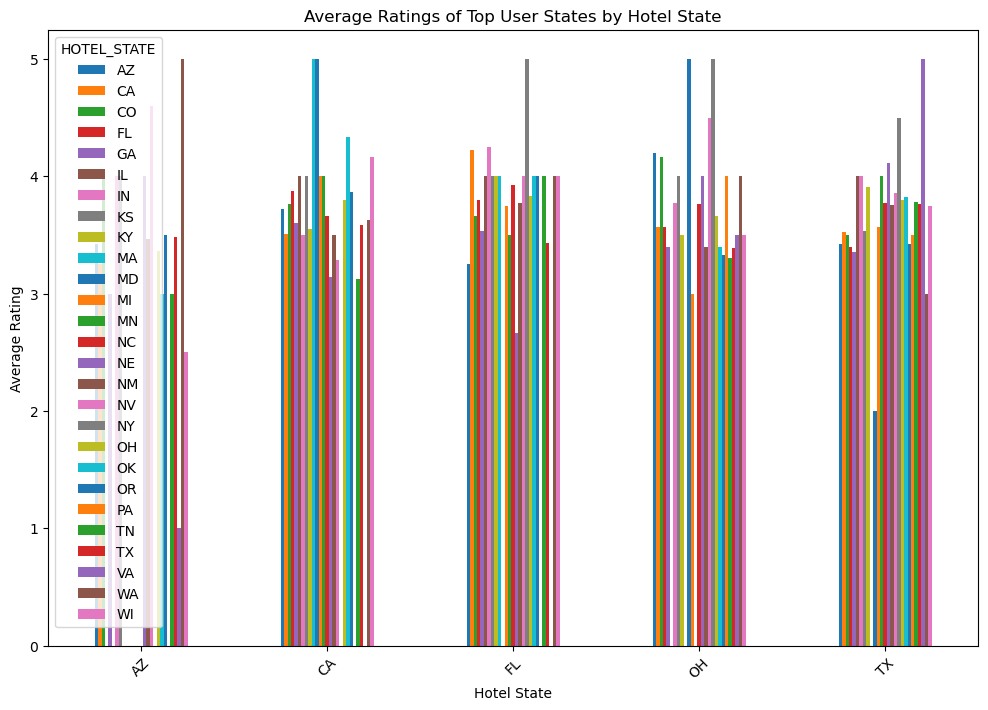

In [36]:

# Pivot the data
pivoted_state = ratings.pivot(index='USER_STATE', columns='HOTEL_STATE', values='Rating')

# Create a figure and axis
fig, ax = plt.subplots(figsize=(12, 8))

# Create a bar chart using pandas
pivoted_state.plot(kind='bar',
                   legend=True,
                   xlabel='Hotel State',
                   ylabel='Average Rating',
                   title='Average Ratings of Top User States by Hotel State',
                   ax=ax,
                   rot=45);  # This sets the rotation directly